# Seismic Signals Analysis

Read, inspect, and visualize seismic traces stored in HDF5 files from SPECFEM2D simulations.

This notebook demonstrates:
- Loading HDF5 seismic data files
- Inspecting file structure and metadata
- Extracting signals from multiple receivers
- Analyzing signal properties
- Plotting time-series data
- Comparing signals across different receiver stations

## 1. Import Required Libraries

import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys

# Add src to path for custom utilities
sys.path.insert(0, str(Path.cwd().parent))
from src.utils.seismic_io import load_traces_from_hdf5, print_hdf5_info

print("✓ All libraries imported successfully")

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys

# Add src to path for custom utilities
sys.path.insert(0, str(Path.cwd().parent))
from src.utils.seismic_io import load_traces_from_hdf5, print_hdf5_info

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load HDF5 File

In [3]:
# Find the latest HDF5 file
h5_dir = Path.cwd().parent / "data/output/h5"
h5_files = sorted(h5_dir.glob("*.h5"), reverse=True)

if not h5_files:
    print("❌ No HDF5 files found in data/output/h5/")
else:
    h5_file = h5_files[0]
    print(f"Loading HDF5 file: {h5_file.name}")
    
    # Load traces and metadata
    traces, metadata = load_traces_from_hdf5(h5_file)
    
    print(f"\n✓ Successfully loaded {len(traces)} traces")
    print(f"Metadata: {metadata}")

Loading HDF5 file: OUTPUT_FILES_2026-06-25_17-23-06.h5

✓ Successfully loaded 25 traces
Metadata: {'dt': np.float64(1.3e-06), 'num_traces': np.int64(25), 'source_x': np.float64(5.0), 'source_z': np.float64(2.8), 'receivers': {'S0001': {'x': 1.0, 'z': 0.5}, 'S0002': {'x': 2.0, 'z': 0.5}, 'S0003': {'x': 3.0, 'z': 0.5}, 'S0004': {'x': 4.0, 'z': 0.5}, 'S0005': {'x': 5.0, 'z': 0.5}, 'S0006': {'x': 6.0, 'z': 0.5}, 'S0007': {'x': 7.0, 'z': 0.5}, 'S0008': {'x': 8.0, 'z': 0.5}, 'S0009': {'x': 9.0, 'z': 0.5}, 'S0010': {'x': 10.0, 'z': 0.5}, 'S0011': {'x': 11.0, 'z': 0.5}, 'S0012': {'x': 12.0, 'z': 0.5}, 'S0013': {'x': 13.0, 'z': 0.5}, 'S0014': {'x': 14.0, 'z': 0.5}, 'S0015': {'x': 15.0, 'z': 0.5}, 'S0016': {'x': 16.0, 'z': 0.5}, 'S0017': {'x': 17.0, 'z': 0.5}, 'S0018': {'x': 18.0, 'z': 0.5}, 'S0019': {'x': 19.0, 'z': 0.5}, 'S0020': {'x': 20.0, 'z': 0.5}, 'S0021': {'x': 21.0, 'z': 0.5}, 'S0022': {'x': 22.0, 'z': 0.5}, 'S0023': {'x': 23.0, 'z': 0.5}, 'S0024': {'x': 24.0, 'z': 0.5}, 'S0025': {'x': 

## 3. Inspect File Structure

In [4]:
print_hdf5_info(h5_file)


HDF5 File: OUTPUT_FILES_2026-06-25_17-23-06.h5

Metadata:
  dt: 1.3e-06
  num_traces: 25
  source_x: 5.0
  source_z: 2.8

Traces: 25 stations
  S0001: 50000 samples, dt=0.000001s, duration=0.065s
  S0002: 50000 samples, dt=0.000001s, duration=0.065s
  S0003: 50000 samples, dt=0.000001s, duration=0.065s
  S0004: 50000 samples, dt=0.000001s, duration=0.065s
  S0005: 50000 samples, dt=0.000001s, duration=0.065s
  ... and 20 more stations

Receivers: 25 stations
  S0001: x=1.0m, z=0.5m
  S0002: x=2.0m, z=0.5m
  S0003: x=3.0m, z=0.5m
  S0004: x=4.0m, z=0.5m
  S0005: x=5.0m, z=0.5m
  ... and 20 more stations



## 4. Extract and Organize Signal Data

In [5]:
# Extract pressure signals as a 2D array (stations x time samples)
station_ids = sorted(traces.keys())
num_stations = len(traces)
num_samples = traces[station_ids[0]]['time'].shape[0]

# Create array to store all pressure data
pressure_data = np.zeros((num_stations, num_samples))

# Fill the array
for i, station_id in enumerate(station_ids):
    pressure_data[i, :] = traces[station_id]['pressure']

# Get common time array and dt
time_array = traces[station_ids[0]]['time']
dt = traces[station_ids[0]]['dt']
duration = (num_samples - 1) * dt

print(f"\n{'='*60}")
print("SIGNAL DATA SUMMARY")
print(f"{'='*60}")
print(f"Number of stations:    {num_stations}")
print(f"Number of samples:     {num_samples}")
print(f"Sampling interval (dt): {dt:.6e} seconds")
print(f"Duration:              {duration:.4f} seconds")
print(f"Time range:            {time_array[0]:.6e} to {time_array[-1]:.6e} s")
print(f"Pressure data shape:   {pressure_data.shape}")


SIGNAL DATA SUMMARY
Number of stations:    25
Number of samples:     50000
Sampling interval (dt): 1.300000e-06 seconds
Duration:              0.0650 seconds
Time range:            -6.000000e-03 to 5.899870e-02 s
Pressure data shape:   (25, 50000)


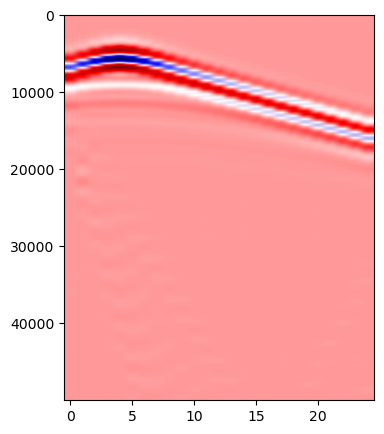

In [6]:


figure = plt.figure(figsize=(4, 5))
plt.imshow(pressure_data.T, aspect='auto', cmap='seismic')

Text(0.5, 0, 'Time (s)')

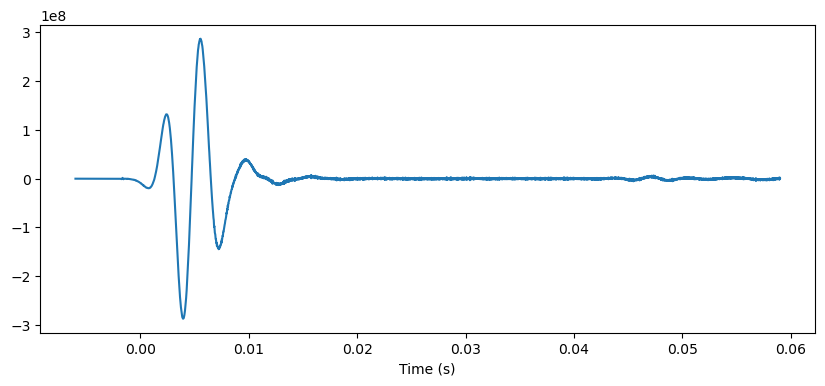

In [7]:
trace = pressure_data[10, :]
time = time_array
plt.figure(figsize=(10, 4))
plt.plot(time, trace)
plt.xlabel("Time (s)")

## 5. Analyze Signal Properties

In [8]:
# Calculate statistics for each station
stats_list = []
for station_id in station_ids:
    pressure = traces[station_id]['pressure']
    stats_list.append({
        'Station': station_id,
        'Mean': np.mean(pressure),
        'Std Dev': np.std(pressure),
        'Min': np.min(pressure),
        'Max': np.max(pressure),
        'Amplitude': np.max(np.abs(pressure))
    })

# Create DataFrame for easy viewing
stats_df = pd.DataFrame(stats_list)

print("\n" + "="*80)
print("SIGNAL STATISTICS BY STATION")
print("="*80)
print(stats_df.to_string(index=False))

# Display source and receiver information if available
print("\n" + "="*80)
print("GEOMETRY INFORMATION")
print("="*80)

if 'source_x' in metadata and 'source_z' in metadata:
    print(f"Source position: x={metadata['source_x']:.1f}m, z={metadata['source_z']:.1f}m")

if 'receivers' in metadata:
    print(f"\nReceiver positions (first 5):")
    receivers = metadata['receivers']
    for i, (station_id, coords) in enumerate(sorted(receivers.items())[:5]):
        print(f"  {station_id}: x={coords['x']:.1f}m, z={coords['z']:.1f}m")
    if len(receivers) > 5:
        print(f"  ... and {len(receivers) - 5} more receivers")


SIGNAL STATISTICS BY STATION
Station          Mean      Std Dev           Min          Max    Amplitude
  S0001   -304.065104 5.915012e+07 -3.621939e+08 2.808961e+08 3.621939e+08
  S0002    626.383758 6.666523e+07 -4.335494e+08 2.932003e+08 4.335494e+08
  S0003   -268.058012 8.213225e+07 -5.548707e+08 3.555041e+08 5.548707e+08
  S0004  -1607.010317 1.017846e+08 -6.990250e+08 4.603753e+08 6.990250e+08
  S0005  -1409.276637 1.128140e+08 -7.758279e+08 5.195245e+08 7.758279e+08
  S0006   -671.923787 1.019287e+08 -7.044918e+08 4.595462e+08 7.044918e+08
  S0007  47897.487315 8.181791e+07 -5.555495e+08 3.527883e+08 5.555495e+08
  S0008  37389.142707 6.740569e+07 -4.387127e+08 2.942344e+08 4.387127e+08
  S0009  40472.829722 5.946491e+07 -3.647672e+08 2.869346e+08 3.647672e+08
  S0010   2526.807002 5.465172e+07 -3.181151e+08 2.866557e+08 3.181151e+08
  S0011 -28723.580273 5.136340e+07 -2.871201e+08 2.869712e+08 2.871201e+08
  S0012  20553.066078 4.888769e+07 -2.637483e+08 2.847773e+08 2.847773

In [9]:
pressure.shape

(50000,)

## 6. Plot Individual Time-Series Signals

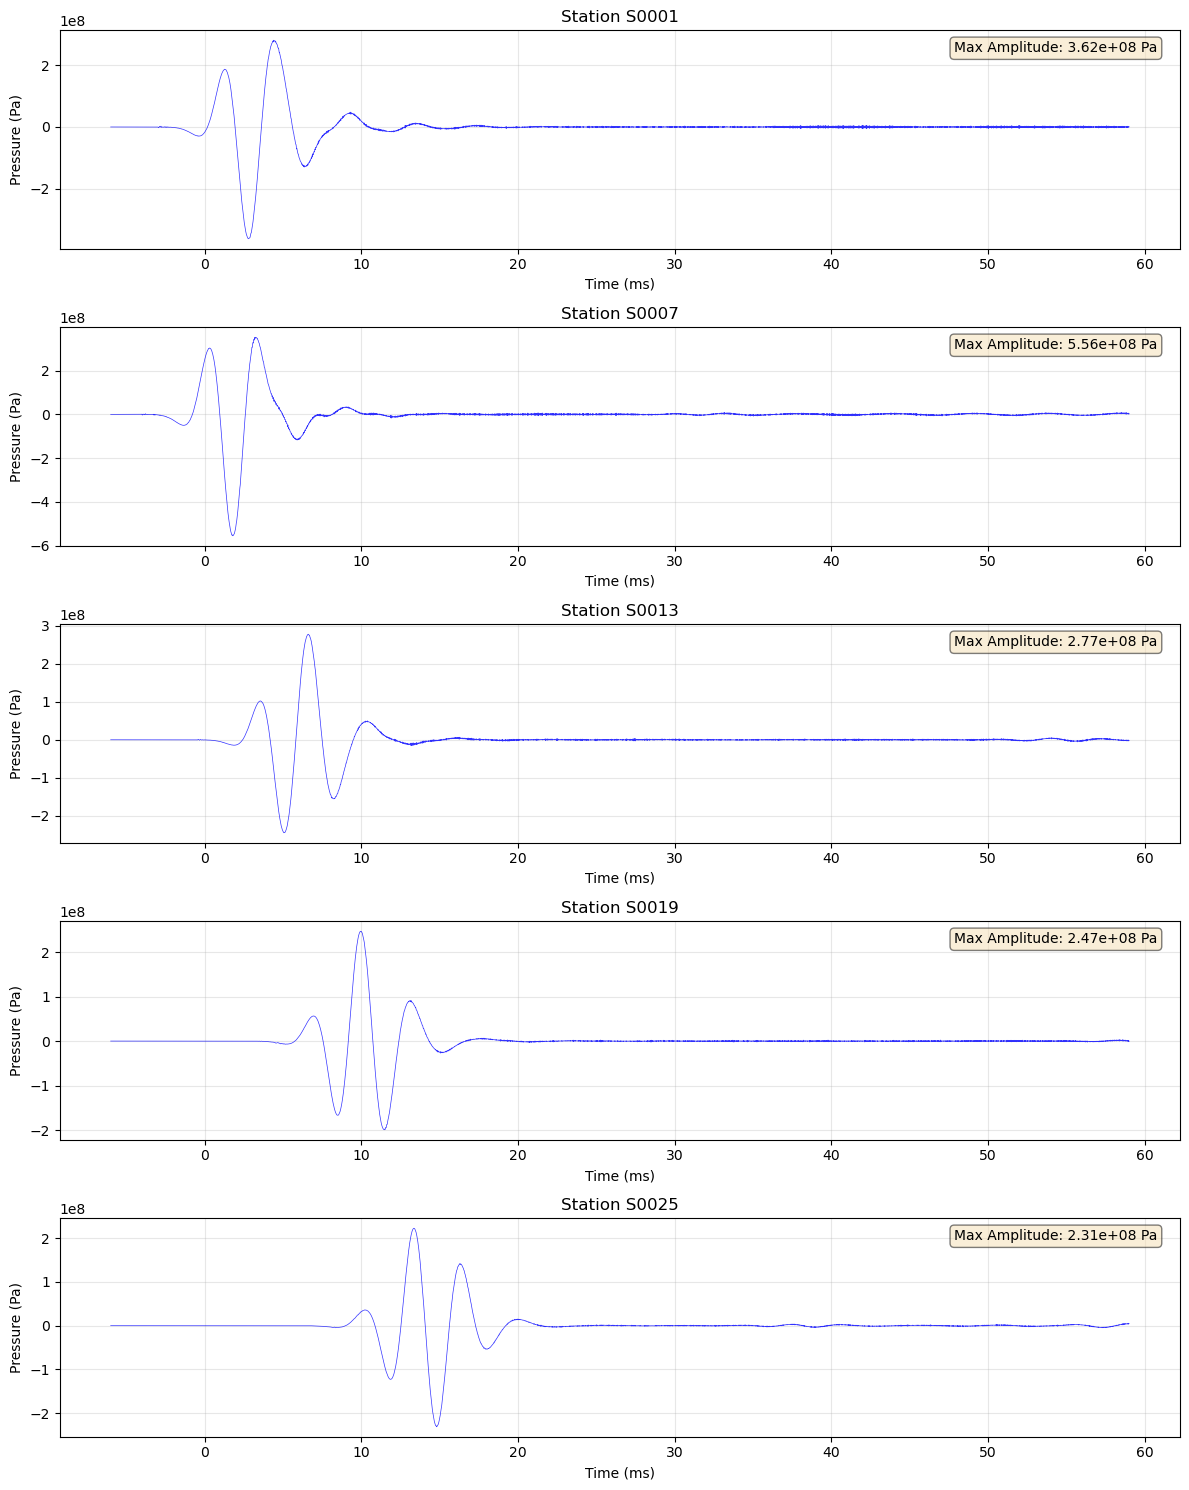

In [10]:
# Select a few stations to plot
selected_stations = station_ids[::6]  # Every 6th station
num_plots = len(selected_stations)

fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3*num_plots))
if num_plots == 1:
    axes = [axes]

for idx, (ax, station_id) in enumerate(zip(axes, selected_stations)):
    time = traces[station_id]['time']
    pressure = traces[station_id]['pressure']
    
    ax.plot(time * 1000, pressure, 'b-', linewidth=0.5, alpha=0.8)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Pressure (Pa)')
    ax.set_title(f'Station {station_id}')
    ax.grid(True, alpha=0.3)
    
    # Add statistics to title
    max_pressure = np.max(np.abs(pressure))
    ax.text(0.98, 0.95, f'Max Amplitude: {max_pressure:.2e} Pa',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 7. All Signals Comparison (Normalized)

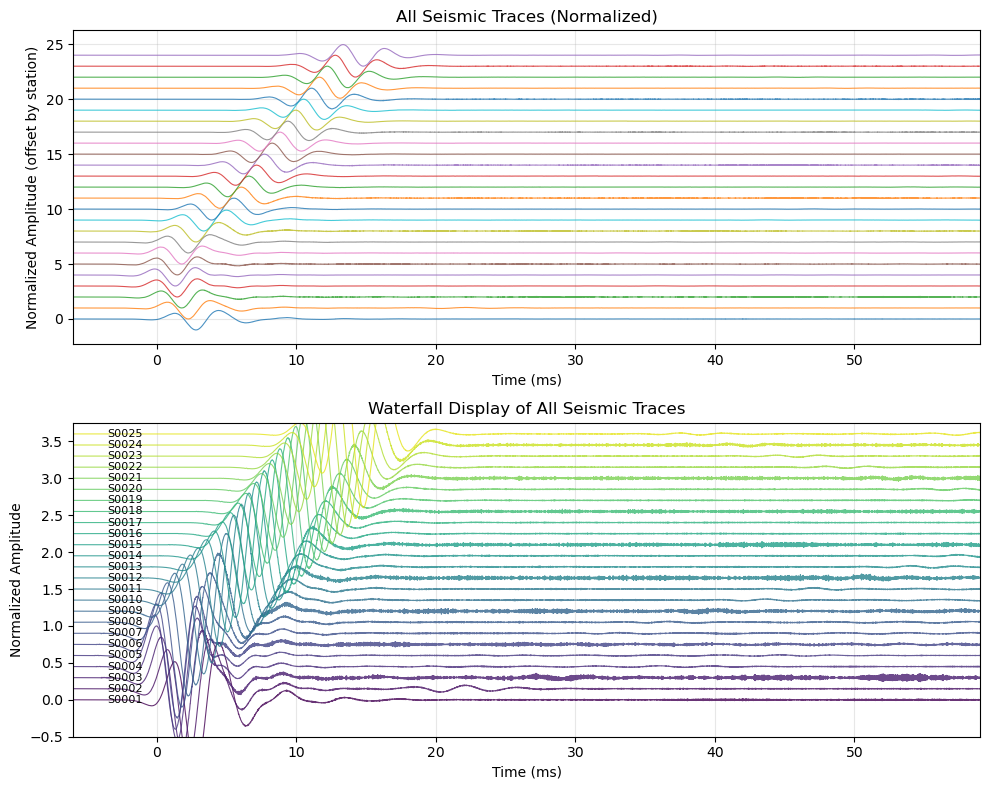

In [11]:
# Plot all signals normalized by their maximum amplitude
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Normalized traces
time_ms = time_array * 1000
for i, station_id in enumerate(station_ids):
    pressure = traces[station_id]['pressure']
    max_pressure = np.max(np.abs(pressure))
    normalized = pressure / max_pressure if max_pressure > 0 else pressure
    ax1.plot(time_ms, normalized + i, label=f'{station_id}', linewidth=0.8, alpha=0.8)

ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Normalized Amplitude (offset by station)')
ax1.set_title('All Seismic Traces (Normalized)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(time_ms[0], time_ms[-1])

# Plot 2: Waterfall style (stacked)
for i, station_id in enumerate(station_ids):
    pressure = traces[station_id]['pressure']
    max_pressure = np.max(np.abs(pressure))
    normalized = pressure / max_pressure if max_pressure > 0 else pressure
    offset = i * 0.15  # Offset for better visibility
    ax2.plot(time_ms, normalized + offset, color=plt.cm.viridis(i/len(station_ids)), 
            linewidth=0.8, alpha=0.8)
    ax2.text(-1, offset, station_id, fontsize=8, ha='right', va='center')

ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Normalized Amplitude')
ax2.set_title('Waterfall Display of All Seismic Traces')
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim(time_ms[0], time_ms[-1])
ax2.set_ylim(-0.5, len(station_ids) * 0.15)

plt.tight_layout()
plt.show()

## 8. Receiver and Source Geometry Visualization

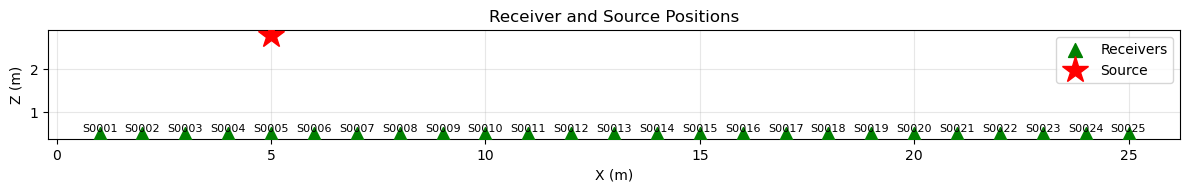

In [12]:
if 'receivers' in metadata:
    fig, ax = plt.subplots(figsize=(12, 4))
    
    receivers = metadata['receivers']
    rx_x = [receivers[station_id]['x'] for station_id in sorted(receivers.keys())]
    rx_z = [receivers[station_id]['z'] for station_id in sorted(receivers.keys())]
    
    # Plot receivers
    ax.scatter(rx_x, rx_z, c='green', s=100, marker='^', label='Receivers', zorder=3)
    
    # Add station labels
    for station_id in sorted(receivers.keys()):
        x = receivers[station_id]['x']
        z = receivers[station_id]['z']
        ax.text(x, z + 0.05, station_id, ha='center', fontsize=8)
    
    # Plot source
    if 'source_x' in metadata and 'source_z' in metadata:
        ax.plot(metadata['source_x'], metadata['source_z'], 'r*', markersize=20, 
               label='Source', zorder=4)
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Z (m)')
    ax.set_title('Receiver and Source Positions')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Receiver geometry not available in metadata")

## 9. Frequency Analysis (Bonus)

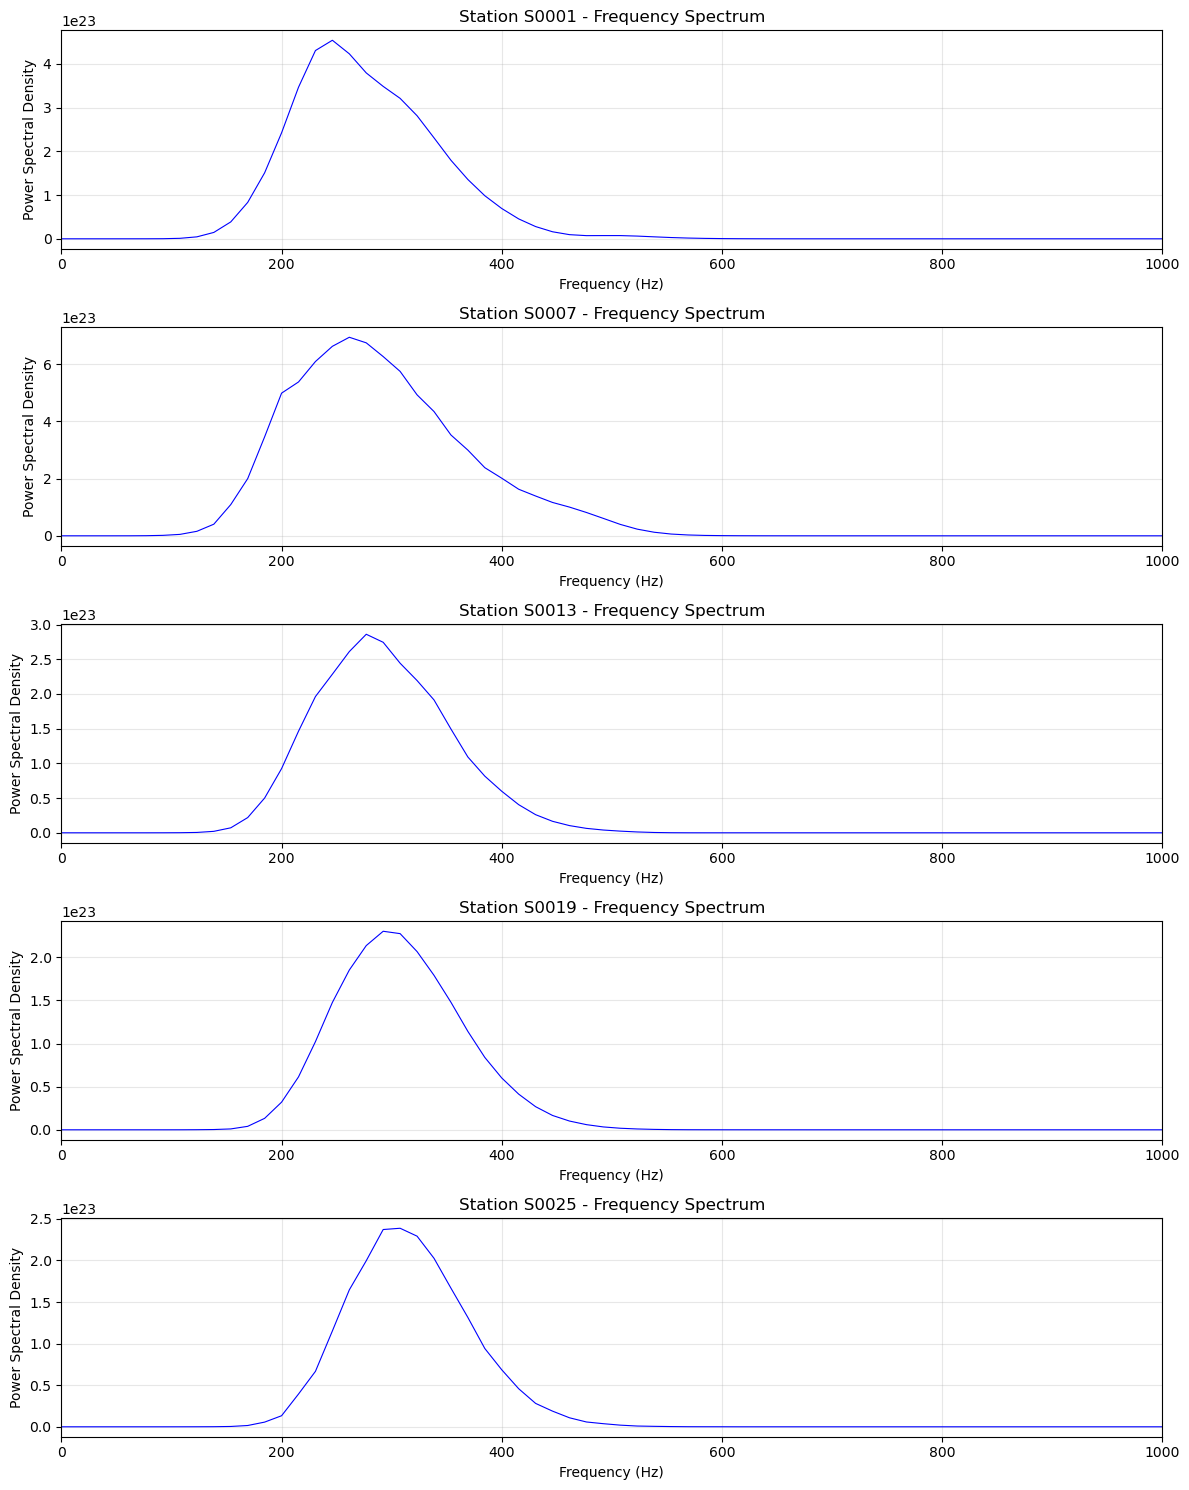


Frequency range: 0 to 384600.0 Hz
Frequency resolution: 15.38 Hz


In [13]:
# Compute FFT for selected stations
fig, axes = plt.subplots(len(selected_stations), 1, figsize=(12, 3*len(selected_stations)))
if len(selected_stations) == 1:
    axes = [axes]

freq_hz = np.fft.fftfreq(num_samples, dt)
freq_hz = freq_hz[:num_samples//2]  # Only positive frequencies

for ax, station_id in zip(axes, selected_stations):
    pressure = traces[station_id]['pressure']
    
    # Compute FFT
    fft_data = np.fft.fft(pressure)
    power = np.abs(fft_data[:num_samples//2]) ** 2
    

    ax.plot(freq_hz, power, 'b-', linewidth=0.8)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power Spectral Density')
    ax.set_title(f'Station {station_id} - Frequency Spectrum')
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim(0, min(1000, freq_hz[-1]))  # Limit to 1000 Hz for clarity

plt.tight_layout()
plt.show()

print(f"\nFrequency range: 0 to {freq_hz[-1]:.1f} Hz")
print(f"Frequency resolution: {freq_hz[1] - freq_hz[0]:.2f} Hz")